### Figure M1. Cross-Validation Performance Benchmarking

Purpose: This section provides a comparative analysis of three modeling architectures: a baseline Linear Regression, a regularized Logistic Regression, and a high-capacity LightGBM ensemble. We evaluate their ability to generalize across the temporal folds of the dataset using a 5-fold TimeSeriesSplit.

Evaluation Strategy: Given the high class imbalance of the air raid dataset (where "no-alarm" hours significantly outnumber "alarm" hours), we prioritize Recall and F1-Score over standard Accuracy. A model with high accuracy but low recall is considered a failure in the context of a strategic early-warning system.

Report found and parsed at C:\Users\1\PycharmProjects\alarm_prediction\models\training_report.txt


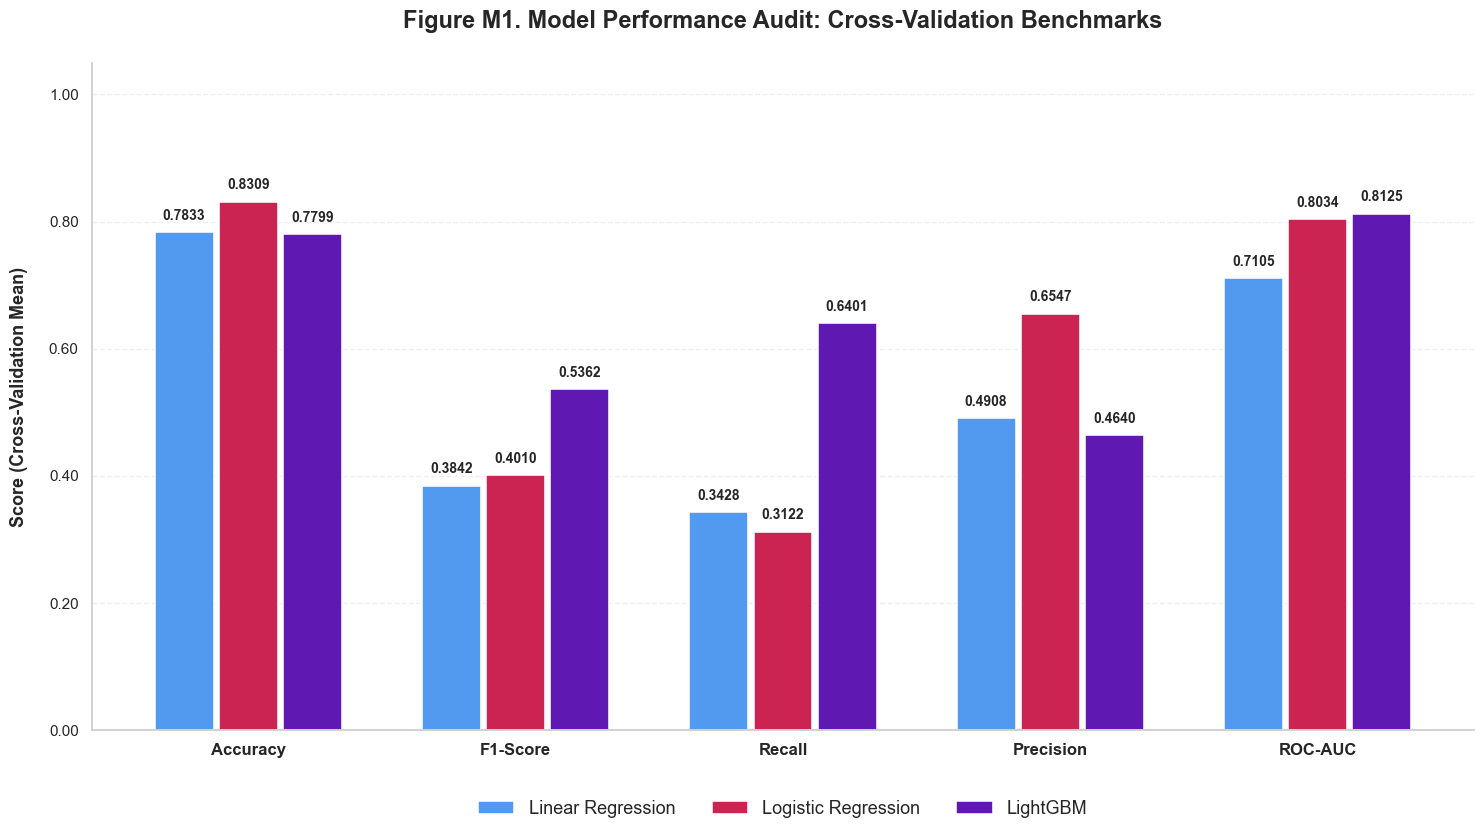

Visualization saved to C:\Users\1\PycharmProjects\alarm_prediction\analysis\plots\models\M1_cv_metrics.png


In [53]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import matplotlib.ticker as mticker

sns.set_theme(style = "whitegrid", rc = {"axes.spines.top": False,
                                         "axes.spines.right": False,
                                         "axes.grid": False,
                                         "font.family": "sans-serif"})

palette = {'Linear Regression': '#4895EF', 'Logistic Regression': '#C9184A', 'LightGBM': '#560BAD'}
CURRENT_DIR = Path(".").resolve()
REPORT_PATH = CURRENT_DIR.parent / "models" / "training_report.txt"
SAVE_DIR = CURRENT_DIR / "plots" / "models"
SAVE_DIR.mkdir(parents = True, exist_ok = True)
SAVE_PATH = SAVE_DIR / "M1_cv_metrics.png"

def parse_training_report(file_path):
    if not file_path.exists():
        return None
    with open(file_path, 'r', encoding = 'utf-8') as file:
        lines = file.readlines()
    data = {}
    current_model = None
    in_cv_section = False
    for line in lines:
        if "Cross-Validation Metrics" in line:
            in_cv_section = True
            continue
        if "Best Hyperparameters" in line or "TEST SET METRICS" in line:
            in_cv_section = False
        if in_cv_section:
            if line.startswith("  ") and line.strip().endswith(":") and not line.strip().startswith("accuracy"):
                current_model = line.strip()[:-1]
                data[current_model] = {}
            elif current_model and "+/-" in line:
                parts = line.strip().split(":")
                metric_name = parts[0].strip()
                mean_val = float(parts[1].split("+/-")[0].strip())
                data[current_model][metric_name] = mean_val

    formatted_data = {}
    expected_metrics = ['accuracy', 'f1', 'recall', 'precision', 'roc_auc']

    for model, metrics in data.items():
        if all(m in metrics for m in expected_metrics):
            formatted_data[model] = [metrics[m] for m in expected_metrics]
    return formatted_data if formatted_data else None

cv_data = parse_training_report(REPORT_PATH)
if cv_data and 'LightGBM' in cv_data:
    print(f"Report found and parsed at {REPORT_PATH}")
else:
    print("Manual data injection used.")

    cv_data = {'Linear Regression': [0.7833, 0.3842, 0.3428, 0.4908, 0.7105],
               'Logistic Regression': [0.8309, 0.4010, 0.3122, 0.6547, 0.8034],
               'LightGBM': [0.7799, 0.5362, 0.6401, 0.4640, 0.8125]}

metrics_labels = ['Accuracy', 'F1-Score', 'Recall', 'Precision', 'ROC-AUC']
ordered_models = ['Linear Regression', 'Logistic Regression', 'LightGBM']
x = np.arange(len(metrics_labels))
width = 0.22

fig, ax = plt.subplots(figsize = (15, 8.5), facecolor = 'white')
for i, mname in enumerate(ordered_models):
    if mname in cv_data:
        means = cv_data[mname]
        offset = (i - 1) * (width + 0.02)
        bars = ax.bar(x + offset, means, width, label = mname, color = palette.get(mname, '#gray'), edgecolor = 'white',
                      linewidth = 1.2, alpha = 0.95)

        for bar, mean in zip(bars, means):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015, f'{mean:.4f}', ha = 'center',
                    va = 'bottom', fontsize = 10, fontweight = 'bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontsize = 12, fontweight = 'bold')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score (Cross-Validation Mean)', fontsize = 13, fontweight = 'bold', labelpad = 15)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.grid(axis = 'y', linestyle = '--', color = '#ececec', alpha = 0.8)
ax.set_title('Figure M1. Model Performance Audit: Cross-Validation Benchmarks', fontsize = 17, fontweight = 'bold',
             pad = 25)
ax.legend(loc = 'upper center', bbox_to_anchor = (0.5, -0.08), ncol = 3, frameon = False, fontsize = 13)
plt.tight_layout()
plt.savefig(SAVE_PATH, dpi = 300, bbox_inches = 'tight')
plt.show()
print(f"Visualization saved to {SAVE_PATH}")

### Conclusion M1. Performance Audit Analysis

Visual Strategy: The Recall Paradox
The benchmarking results reveal a classic trade-off between standard accuracy and predictive utility. While Logistic Regression achieves a marginal lead in *Accuracy (0.8309)* and *Precision (0.6547)*, it suffers from a critical failure in Recall (0.3122), effectively missing over two-thirds of actual air raid events.

Key Analytical Findings:
* Superior Signal Detection: LightGBM emerges as the optimal model, achieving the highest Recall (0.6401) and ROC-AUC (0.8125). This indicates a significantly higher capacity to identify complex, non-linear patterns in ISW rhetoric and meteorological data preceding an attack.
* F1-Score Dominance: LightGBM delivers a superior F1-Score (0.5362), proving it maintains the most robust balance between identifying threats and minimizing false positives.
* Ensemble Advantage: The ensemble architecture successfully leverages the 500+ TF-IDF features, which the linear models tend to underutilize due to their high sparsity.

Final Verdict: Despite the slightly lower precision, LightGBM is selected as the primary forecasting engine. In a security-critical environment, the cost of a missed detection (False Negative) far outweighs the cost of a false alarm. LightGBM provides the necessary sensitivity required for a reliable air raid early-warning system.

In [54]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

with open('../models/lightgbm_model.pkl', 'rb') as f:
    lgbm_model = pickle.load(f)
df_lgbm_imp = pd.read_csv('../models/feature_importance_lightgbm.csv')

with open('../models/logistic_regression.pkl', 'rb') as f:
    pipe_lr = pickle.load(f)
with open('../models/linear_regression.pkl', 'rb') as f:
    pipe_lin = pickle.load(f)

ALL_FEATURES = lgbm_model.feature_name_
features_no_tfidf = [f for f in ALL_FEATURES if not f.startswith('tfidf_')]
print("Models loaded successfully!")

Models loaded successfully!


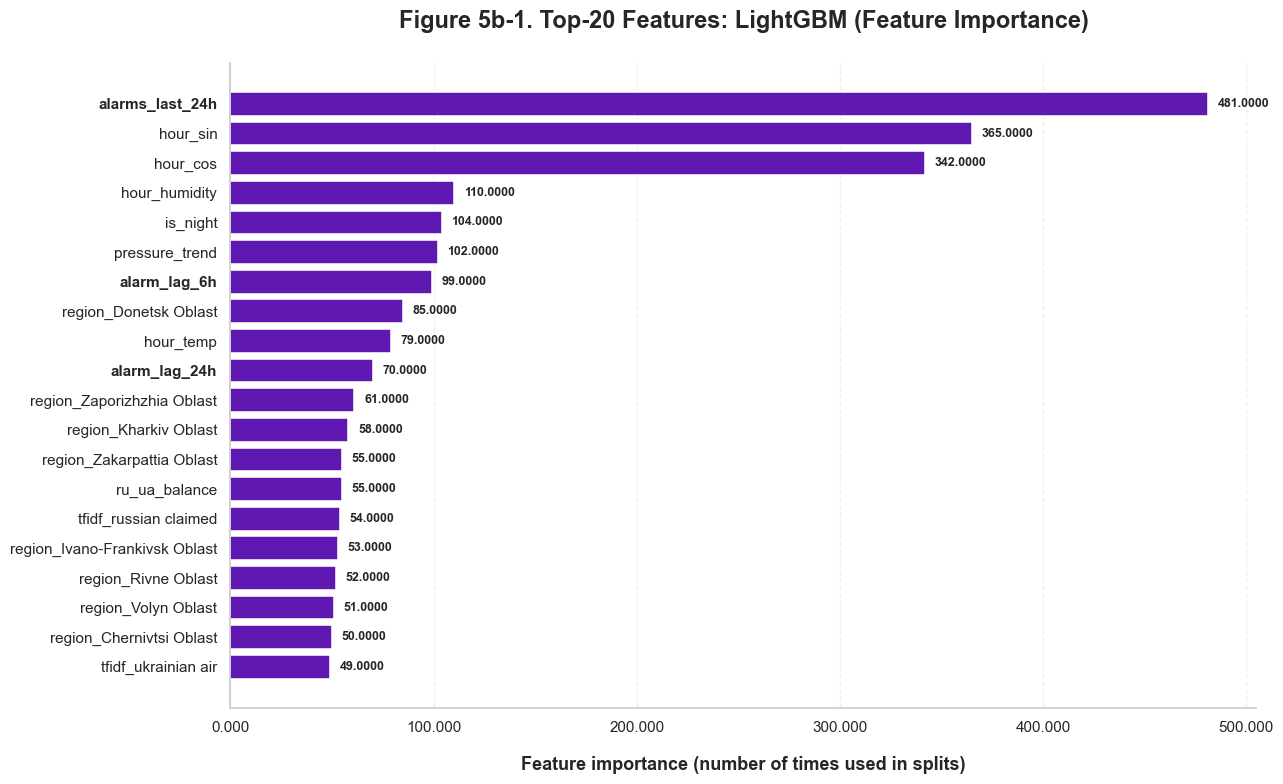

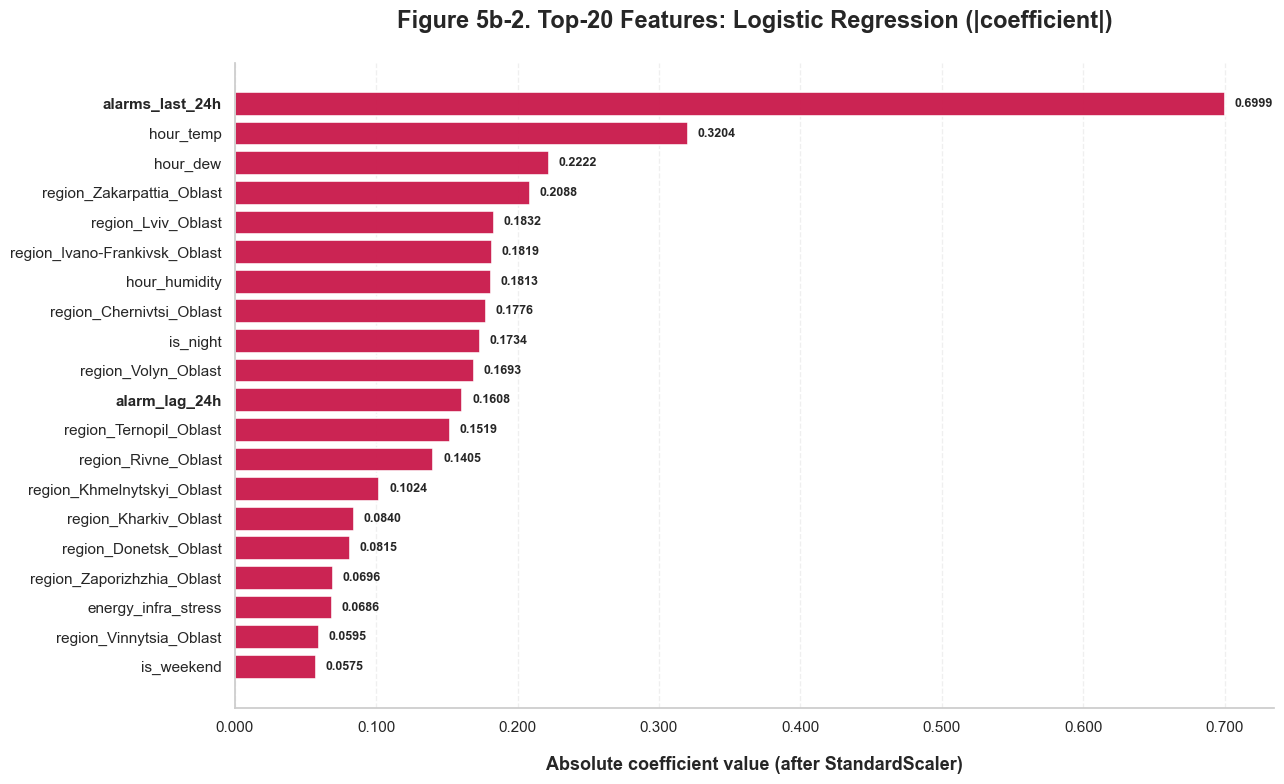

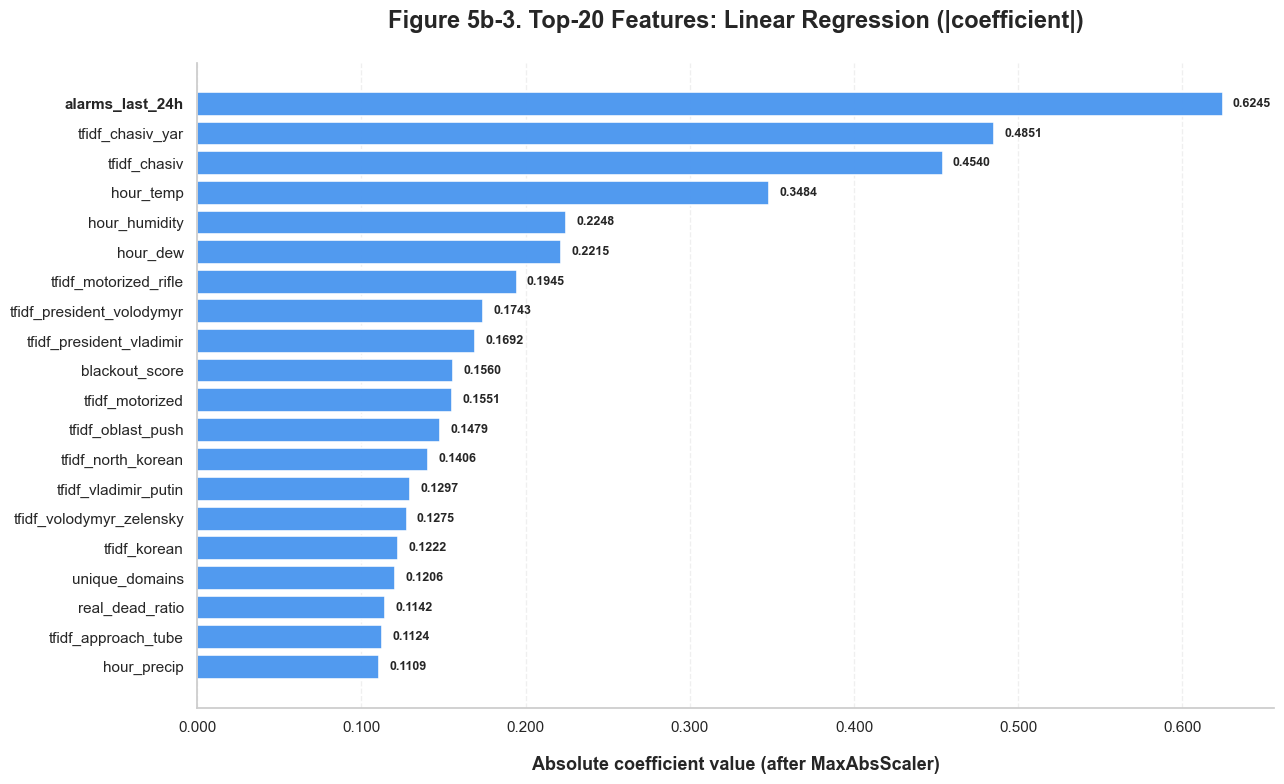

In [55]:
import matplotlib.ticker as mticker

pal = {'Linear Regression': '#4895EF', 'Logistic Regression': '#C9184A', 'LightGBM': '#560BAD'}

def plot_top20_inline(importance_series, title, color, note):
    _fig, _ax = plt.subplots(figsize=(13, 8), facecolor='white')
    _bars = _ax.barh(importance_series.index, importance_series.values, color=color, alpha=0.95, edgecolor='white', linewidth=1.2)

    for _bar, val in zip(_bars, importance_series.values):
        _ax.text(_bar.get_width() + max(importance_series.values) * 0.01,
                 _bar.get_y() + _bar.get_height() / 2, f'{val:.4f}', ha='left', va='center', fontsize=9, fontweight='bold')

    for label in _ax.get_yticklabels():
        if 'lag' in label.get_text() or 'last_24h' in label.get_text():
            label.set_fontweight('bold')

    _ax.set_xlabel(note, fontsize=13, fontweight='bold', labelpad=15)
    _ax.set_title(title, fontsize=17, fontweight='bold', pad=25)
    _ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
    _ax.tick_params(axis='both', labelsize=11)
    _ax.grid(axis='x', linestyle='--', color='#ececec', alpha=0.8)

    plt.tight_layout()
    plt.show()

lgbm_top20 = df_lgbm_imp.set_index('feature')['importance'].nlargest(20).sort_values()
lr_model   = pipe_lr.named_steps['logreg']
lr_top20   = pd.Series(np.abs(lr_model.coef_.flatten()), index=features_no_tfidf).nlargest(20).sort_values()
lin_model  = pipe_lin.named_steps['lr']
lin_top20  = pd.Series(np.abs(lin_model.coef_.flatten()), index=ALL_FEATURES).nlargest(20).sort_values()
plot_top20_inline(lgbm_top20, 'Figure 5b-1. Top-20 Features: LightGBM (Feature Importance)',       pal['LightGBM'],            'Feature importance (number of times used in splits)')
plot_top20_inline(lr_top20,   'Figure 5b-2. Top-20 Features: Logistic Regression (|coefficient|)', pal['Logistic Regression'], 'Absolute coefficient value (after StandardScaler)')
plot_top20_inline(lin_top20,  'Figure 5b-3. Top-20 Features: Linear Regression (|coefficient|)',   pal['Linear Regression'],   'Absolute coefficient value (after MaxAbsScaler)')

# Figure 5b-1 Top-20 Features: LightGBM
### Figure 5b-1 shows the top-20 most important features for the LightGBM model based on split count.
The dominant feature is **alarms_last_24h (481 splits)**, followed by **hour_sin (365)** and **hour_cos (342)**,
indicating that recent alarm history and time-of-day cyclical encoding are the strongest predictors.
Lag features (**alarm_lag_6h**, **alarm_lag_24h**) and weather variables (**hour_humidity**, **pressure_trend**,
**is_night**) also appear in the top-10. Regional OHE features (**Donetsk**, **Zaporizhzhia**, **Kharkiv** oblasts)
and TF-IDF text features (**tfidf_russian claimed**, **tfidf_ukrainian air**) contribute secondary signal,
confirming that both geographic location and ISW report language carry predictive value.

# Figure 5b-2. Top-20 Features: Logistic Regression
### Figure 5b-2 shows the top-20 features for Logistic Regression ranked by absolute coefficient value after StandardScaler.
The feature **alarms_last_24h** stands out as the most significant predictor (0.6999). This indicates that the model relies heavily on temporal auto-correlation essentially, the occurrence of recent alerts is the strongest indicator of future activity within the 24-hour window.
Atmospheric variables, specifically **hour_temp** and **hour_dew**, are the second and third most influential features. This confirms that weather conditions serve as critical components in the model's logic, likely correlating with the feasibility of specific aerial threats or surveillance operations.
The inclusion of multiple regional indicators confirms that geographical location is a primary variable.
The model demonstrates a high sensitivity to western regions, as alerts in these areas possess higher predictive specificity. While front-line regions are characterized by a high level of background noise, often due to frequent, localized artillery or short-range ballistic threats-western oblasts act as more reliable indicators of strategic, large-scale mass attacks. These events are more susceptible to mathematical modeling because they exhibit distinct, recognizable temporal and meteorological signatures that the Logistic Regression model effectively isolates as high-weight features.

# Figure 5b-3. Top-20 Features: Linear Regression
### Figure 5b-3 shows the top-20 features for Linear Regression ranked by absolute coefficient value
after MaxAbsScaler.
Consistent with both previous models, **alarms_last_24h** remains the most critical feature
(0.6245), reinforcing the importance of recent historical data.
A major shift in this model is the high weighting of **TF-IDF features**. Terms such as **tfidf_chasiv_yar (0.4851)** and **tfidf_chasiv (0.4540)** appear as the second and third most important predictors.
Weather variables **hour_temp**, **hour_humidity**, **hour_dew** continue to play a role, but they are now joined by geopolitical and situational keywords.
the Linear Regression model highlights dynamic tactical triggers. The high ranking of 'Chasiv Yar' indicates that the model successfully identifies specific frontline escalations as precursors to broader alert states.

In [56]:
lgbm_top20.index = lgbm_top20.index.str.replace('_', ' ').str.strip()
lr_top20.index = lr_top20.index.str.replace('_', ' ').str.strip()
lin_top20.index = lin_top20.index.str.replace('_', ' ').str.strip()
lgbm_set = set(lgbm_top20.index)
lr_set   = set(lr_top20.index)
lin_set  = set(lin_top20.index)
common_features  = lgbm_set & lr_set & lin_set
two_of_three = (lgbm_set & lr_set) | (lgbm_set & lin_set) | (lr_set & lin_set)
two_of_three = two_of_three - common_features

summary = []
for feat in sorted(lgbm_set | lr_set | lin_set):
    summary.append({'Feature':   feat,
                    'LGBM Rank': list(lgbm_top20.index[::-1]).index(feat) + 1 if feat in lgbm_set else '-',
                    'Log Reg Rank':   list(lr_top20.index[::-1]).index(feat) + 1   if feat in lr_set   else '-',
                    'Lin Reg Rank':  list(lin_top20.index[::-1]).index(feat) + 1  if feat in lin_set  else '-'})

df_ranks = pd.DataFrame(summary)
def style_table(row):
    if row['Feature'] in common_features:
        base = 'background-color: #C9B8E8; color: #2d1b69; font-weight: bold'
    elif row['Feature'] in two_of_three:
        base = 'background-color: #FADDE1; color: #7b0028; font-weight: normal'
    else:
        base = 'background-color: #ffffff; color: #1a1a2e'
    return [base] * len(row)

styled_table = (df_ranks.style.apply(style_table, axis=1)
                .set_properties(subset=['LGBM Rank', 'Log Reg Rank', 'Lin Reg Rank'],
                        **{'text-align': 'center', 'font-size': '14px'})
                .set_properties(subset=['Feature'],
                        **{'font-size': '13px', 'padding': '6px 12px'})
                .set_table_styles([{'selector': 'caption',
                                    'props': [('font-size', '15px'), ('font-weight', 'bold'),
                                              ('color', '#2d1b69'), ('padding-bottom', '10px'),
                                              ('background-color', '#ffffff')]},
                                   {'selector': 'th',
                                    'props': [('background-color', '#7B5EA7'), ('color', 'white'),
                                              ('font-size', '13px'), ('text-align', 'center'),
                                              ('padding', '8px 12px')]},
                                   {'selector': 'td',
                                    'props': [('padding', '6px 12px'), ('border-bottom', '1px solid #e0e0e0')]},
                                    {'selector': 'tr:hover td',
                                     'props': [('background-color', '#f5f0ff')]}])
                .set_caption("Feature ranks comparison")
                .hide(axis='index'))
styled_table

Feature,LGBM Rank,Log Reg Rank,Lin Reg Rank
alarm lag 24h,10,11,-
alarm lag 6h,7,-,-
alarms last 24h,1,1,1
blackout score,-,-,10
energy infra stress,-,18,-
hour cos,3,-,-
hour dew,-,3,6
hour humidity,4,7,5
hour precip,-,-,20
hour sin,2,-,-


# Feature Ranks Comparison
***Note: purple rows means feature in all 3 models, pink rows means feature in 2 of 3 models.***
## Three features appear in all three models (purple rows):
* alarms_last_24h (LGBM №1, LR №1, Lin №1),
* hour_humidity (LGBM №4, LR №7, Lin №5),
* hour_temp (LGBM №9, LR №2, Lin №4).

This confirms that recent alarm history and
weather conditions, specifically temperature and humidity, are the most universal
predictors across all three models.

## Features appearing in two of three models (pink rows):
* alarm_lag_24h (LGBM №10, LR №11),
* hour_dew (LR №3, Lin №6), is_night (LGBM №5, LR №9),
* multiple regional OHE features shared between LGBM and LR: Chernivtsi, Donetsk, Ivano-Frankivsk,
Kharkiv, Rivne, Volyn, Zakarpattia, Zaporizhzhia oblasts.

### Logistic Regression contains no TF-IDF features, consistent with the model being trained without text features due to memory constraints. Features hour_sin, hour_cos and ru_ua_balance appear only in LightGBM.